# LightGBM — Optuna Hyperparameter Tuning (NaN Native) — AUC-PR Hedefli (V2)
## IEEE-CIS Fraud Detection | Hiperparametre Optimizasyonu

**Amaç:** LightGBM hiperparametrelerini Optuna TPE ile optimize etmek.
Operasyonel hedef Recall ≥ 0.85 olduğundan, objective **AUC-PR** (average_precision_score) ile maksimize edilir.
F2, Recall'u Precision'dan **2× fazla** ağırlandırır.

**v1 (F2) ile fark:** Objective fonksiyonu AUC-PR olarak güncellendi (adil karşılaştırma).
Pipeline, arama uzayı, trial sayısı, veri bölme — hepsi özdeş → adil karşılaştırma korunur.

**Pipeline:**
| Adım | Açıklama |
|------|----------|
| NaN stratejisi | Native — imputation YOK |
| D normalizasyonu | `D_norm = D − TransactionDT/86400` (Chris Deotte) |
| UID | `card1 + addr1 + D1n` |
| Val split | Kronolojik son %20 |
| Target encoding | 2 aşamalı (UID: val-öncesi, Kategorik: val-sonrası) |
| Optuna | TPESampler(seed=42), pruner YOK, 100 trial, **F2 hedefli** |

**Metrik:** AUC-PR (birincil raporlama), AUC-ROC (ikincil), Recall/Precision @ çeşitli eşikler

## 1. Kütüphaneler

In [ ]:
import os, gc, time, warnings, pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)

try:
    import optuna
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'optuna', '-q'], check=True)
    import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

_t0_total = time.time()
print(f'LightGBM version : {lgb.__version__}')
print(f'Optuna version   : {optuna.__version__}')
print('Kutuphaneler yuklendi.')

LightGBM version : 4.6.0
Optuna version   : 4.8.0
Kutuphaneler yuklendi.


## 2. Bellek Optimizasyonu

In [ ]:
def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    '''Sayisal sutunlarin veri tipini kuculterek RAM kullanimi azaltir.'''
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
        else:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(
            f'Bellek: {start_mem:.1f} MB -> {end_mem:.1f} MB '
            f'({100*(start_mem - end_mem)/start_mem:.1f}% azaldi)'
        )
    return df

## 3. Veri Yükleme

In [ ]:
_t_start = time.time()

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATA_PATH = '/content/drive/My Drive/Bitirme/VeriSeti'
TRAIN_PATH = f'{DRIVE_DATA_PATH}/train_transaction.csv'
IDENT_PATH = f'{DRIVE_DATA_PATH}/train_identity.csv'

# Cikti klasoru (15-Mayis-Cuma)
SAVE_BASE = '/content/drive/My Drive/Bitirme/15-Mayıs-Cuma/'
os.makedirs(SAVE_BASE, exist_ok=True)
print(f'Cikti klasoru : {SAVE_BASE}')

assert os.path.exists(TRAIN_PATH), f'HATA: Dosya bulunamadi -> {TRAIN_PATH}'
assert os.path.exists(IDENT_PATH), f'HATA: Dosya bulunamadi -> {IDENT_PATH}'
print('Dosyalar dogrulandi.')

df_tx = pd.read_csv(TRAIN_PATH)
df_id = pd.read_csv(IDENT_PATH)
df = df_tx.merge(df_id, on='TransactionID', how='left')
del df_tx, df_id
gc.collect()

df = reduce_mem_usage(df)
print(f'Veri seti: {df.shape[0]:,} satir x {df.shape[1]} sutun')
print(
    f'Fraud orani: {df.isFraud.mean()*100:.2f}% '
    f'({df.isFraud.sum():,} fraud / {len(df):,} toplam)'
)
print(f'[SURE] Veri yukleme: {time.time()-_t_start:.1f} sn')

Mounted at /content/drive
Cikti klasoru : /content/drive/My Drive/Bitirme/15-Mayıs-Cuma/
Dosyalar dogrulandi.
Bellek: 2514.0 MB -> 1603.3 MB (36.2% azaldi)
Veri seti: 590,540 satir x 434 sutun
Fraud orani: 3.50% (20,663 fraud / 590,540 toplam)
[SURE] Veri yukleme: 67.8 sn


## 4. Veri Temizleme ve Kategorik Encoding

**NaN stratejisi:** Sayısal NaN'lar bu adımda **değiştirilmez**. LightGBM kendi içinde NaN'ları işler.
Sadece kategorik (object) sütunlar doldurulur ve label-encode edilir.

In [ ]:
_t_start = time.time()

MISSING_THRESHOLD = 0.80
missing_pct = df.isnull().mean()
df_clean = df.loc[:, missing_pct <= MISSING_THRESHOLD].copy()
print(f'{df.shape[1] - df_clean.shape[1]} sutun atildi (>%80 bos)')
print(f'Kalan sutun: {df_clean.shape[1]}')

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('bilinmiyor')

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean = reduce_mem_usage(df_clean, verbose=False)
print('Temizlik tamamlandi.')
print('NOT: Sayisal NaN degerler DEGISTIRILMEDI — LightGBM native NaN destekler.')
print(f'[SURE] Temizlik: {time.time()-_t_start:.1f} sn')

74 sutun atildi (>%80 bos)
Kalan sutun: 360
Temizlik tamamlandi.
NOT: Sayisal NaN degerler DEGISTIRILMEDI — LightGBM native NaN destekler.
[SURE] Temizlik: 21.6 sn


## 5. Zaman ve Harcama Özellikleri

In [ ]:
_t_start = time.time()

df_clean['tx_hour']     = (df_clean['TransactionDT'] % 86400) // 3600
df_clean['is_night']    = (
    (df_clean['tx_hour'] >= 0) & (df_clean['tx_hour'] < 9)
).astype(np.int8)
df_clean['tx_day']      = df_clean['TransactionDT'] // 86400
df_clean['day_of_week'] = (df_clean['TransactionDT'] // 86400) % 7
df_clean['log_amt']     = np.log1p(df_clean['TransactionAmt']).astype(np.float32)
df_clean['amt_dollars'] = df_clean['TransactionAmt'].astype(np.int32)
df_clean['amt_cents']   = (
    (df_clean['TransactionAmt'] % 1) * 100
).round().astype(np.int8)

print('Zaman ve harcama ozellikleri eklendi.')
print(f'[SURE] Zaman ozellikleri: {time.time()-_t_start:.1f} sn')

Zaman ve harcama ozellikleri eklendi.
[SURE] Zaman ozellikleri: 0.1 sn


## 6. Temporal Split (%80 Train / %20 Test, Kronolojik)

**Leakage kontrolü:** Test seti bu noktadan itibaren sadece final evaluasyonda kullanılır.
Hiçbir istatistik test setinden hesaplanmaz.

In [ ]:
_t_start = time.time()

split_idx = int(len(df_clean) * 0.80)
DROP_COLS_EARLY = ['TransactionID', 'isFraud']

X_train = (
    df_clean.iloc[:split_idx]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_train = df_clean.iloc[:split_idx]['isFraud'].reset_index(drop=True)

X_test = (
    df_clean.iloc[split_idx:]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_test = df_clean.iloc[split_idx:]['isFraud'].reset_index(drop=True)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Egitim seti : {X_train.shape[0]:,} islem | Fraud: {y_train.mean()*100:.2f}%')
print(f'Test seti   : {X_test.shape[0]:,} islem  | Fraud: {y_test.mean()*100:.2f}%')
print(f'pos_weight (dogal): {pos_weight:.2f}')
del df_clean, df
gc.collect()
print(f'[SURE] Temporal split: {time.time()-_t_start:.1f} sn')

Egitim seti : 472,432 islem | Fraud: 3.51%
Test seti   : 118,108 islem  | Fraud: 3.44%
pos_weight (dogal): 27.46
[SURE] Temporal split: 2.5 sn


## 7. Kronolojik Sıralama

Expanding window operasyonları (velocity, target encoding) zaman sırasını varsayar.
Bu adım eksik olursa gelecekteki veri geçmişe "sızar" → leakage.

In [ ]:
_t_start = time.time()

sort_idx_train = X_train['TransactionDT'].argsort(kind='stable')
X_train = X_train.iloc[sort_idx_train].reset_index(drop=True)
y_train = y_train.iloc[sort_idx_train].reset_index(drop=True)

sort_idx_test = X_test['TransactionDT'].argsort(kind='stable')
X_test = X_test.iloc[sort_idx_test].reset_index(drop=True)
y_test = y_test.iloc[sort_idx_test].reset_index(drop=True)

print('TransactionDT siralamasi tamamlandi:')
print(f'  X_train monoton artan: {X_train["TransactionDT"].is_monotonic_increasing}')
print(f'  X_test  monoton artan: {X_test["TransactionDT"].is_monotonic_increasing}')
print(f'[SURE] Siralama: {time.time()-_t_start:.1f} sn')

TransactionDT siralamasi tamamlandi:
  X_train monoton artan: True
  X_test  monoton artan: True
[SURE] Siralama: 0.7 sn


## 8. V Sütunu Grup Seçimi (n_per_group=5)

In [ ]:
_t_start = time.time()

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'tqdm', '-q'], check=True)
    from tqdm.auto import tqdm as _tqdm


def select_v_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_per_group: int = 5,
    bucket_size: float = 0.05,
    min_valid_samples: int = 500,
) -> list:
    '''
    V sutunlarini eksik deger yapisina gore gruplara ayirir.
    Her gruptan en yuksek fraud korelasyonlu n_per_group sutunu secer.
    Sadece X_train ve y_train kullanilir — leakage yok.
    '''
    v_cols = [c for c in X_train.columns if c.startswith('V')]
    if not v_cols:
        return []
    missing_rates = X_train[v_cols].isnull().mean()
    buckets = (missing_rates / bucket_size).astype(int)
    selected = []
    for bucket_id in _tqdm(sorted(buckets.unique()), desc='V grup secimi', unit='grup'):
        cols_in_bucket = buckets[buckets == bucket_id].index.tolist()
        corr_dict = {}
        for col in cols_in_bucket:
            valid_mask = X_train[col].notna()
            if valid_mask.sum() < min_valid_samples:
                continue
            corr_val = abs(X_train.loc[valid_mask, col].corr(y_train[valid_mask]))
            if not np.isnan(corr_val):
                corr_dict[col] = corr_val
        top_cols = sorted(corr_dict, key=corr_dict.get, reverse=True)[:n_per_group]
        selected.extend(top_cols)
    return selected


all_v_cols = [c for c in X_train.columns if c.startswith('V')]
v_selected = select_v_features(X_train, y_train, n_per_group=5)
v_to_drop  = [c for c in all_v_cols if c not in v_selected]
X_train.drop(columns=v_to_drop, inplace=True)
X_test.drop(columns=v_to_drop, inplace=True)

print(f'V secimi: {len(v_selected)} sutun kaldi, {len(v_to_drop)} atildi.')
print(f'[SURE] V sutun secimi: {time.time()-_t_start:.1f} sn')

V grup secimi:   0%|          | 0/6 [00:00<?, ?grup/s]

V secimi: 30 sutun kaldi, 262 atildi.
[SURE] V sutun secimi: 4.5 sn


## 9. NaN Stratejisi — Rapor (Bilgi Amaçlı)

Bu notebook'ta sayısal NaN'lar **değiştirilmez**. LightGBM, NaN'ları kendi içinde işler.

In [ ]:
_t_start = time.time()

nan_report = X_train.isnull().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)

print(f'Train NaN olan sutun sayisi: {len(nan_report)}')
print()
print('Train — En cok NaN iceren 15 sutun:')
for col, cnt in nan_report.head(15).items():
    pct = cnt / len(X_train) * 100
    print(f'  {col:<20}: {cnt:>6,} NaN ({pct:.1f}%)')
print()
print('Bu NaN degerler DEGISTIRILMEYECEK — LightGBM native NaN destekler.')
print(f'[SURE] NaN raporu: {time.time()-_t_start:.1f} sn')

Train NaN olan sutun sayisi: 53

Train — En cok NaN iceren 15 sutun:
  id_13               : 367,262 NaN (77.7%)
  V246                : 362,497 NaN (76.7%)
  V242                : 362,497 NaN (76.7%)
  V233                : 362,497 NaN (76.7%)
  V244                : 362,497 NaN (76.7%)
  V257                : 362,497 NaN (76.7%)
  id_05               : 357,945 NaN (75.8%)
  id_06               : 357,945 NaN (75.8%)
  id_20               : 355,807 NaN (75.3%)
  id_19               : 355,787 NaN (75.3%)
  id_17               : 355,747 NaN (75.3%)
  id_02               : 354,749 NaN (75.1%)
  id_11               : 354,636 NaN (75.1%)
  id_01               : 351,968 NaN (74.5%)
  dist1               : 287,157 NaN (60.8%)

Bu NaN degerler DEGISTIRILMEYECEK — LightGBM native NaN destekler.
[SURE] NaN raporu: 0.1 sn


## 10. D Sütunu Normalizasyonu (Chris Deotte Yöntemi)

**Formül:** `D_norm = D − TransactionDT / 86400`

Bu işlem satır-bazlı bağımsızdır → leakage yok.

In [ ]:
_t_start = time.time()

D_SKIP = {1, 2, 3, 5, 9}

def engineer_d_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    '''
    Chris Deotte D normalizasyonu.
    Formul: D_norm = D - TransactionDT / 86400
    D1 ham degeri korunur (D1n hesabi icin).
    '''
    normalized = []
    for i in range(1, 16):
        if i in D_SKIP:
            continue
        col = f'D{i}'
        if col not in X_train.columns:
            continue
        norm_col = f'{col}_norm'
        tx_day_train = X_train['TransactionDT'] / np.float32(86400)
        tx_day_test  = X_test['TransactionDT']  / np.float32(86400)
        X_train[norm_col] = (X_train[col] - tx_day_train).astype(np.float32)
        X_test[norm_col]  = (X_test[col]  - tx_day_test).astype(np.float32)
        normalized.append(col)
    print(f'D normalizasyonu: {len(normalized)} sutun icin norm ozelligi eklendi.')
    return X_train, X_test


X_train, X_test = engineer_d_features(X_train, X_test)
print(f'[SURE] D normalizasyon: {time.time()-_t_start:.1f} sn')

D normalizasyonu: 4 sutun icin norm ozelligi eklendi.
[SURE] D normalizasyon: 0.0 sn


## 11. D1n Hesaplama ve UID Oluşturma

**UID = card1 + addr1 + D1n** (D1n = floor(tx_day − D1))

D1n, kartın ilk işlem gününden bu yana geçen süreyi temsil eder.

In [ ]:
_t_start = time.time()

if 'D1' in X_train.columns:
    X_train['D1n'] = np.floor(
        X_train['tx_day'] - X_train['D1']
    ).astype(np.float32)
    X_test['D1n'] = np.floor(
        X_test['tx_day'] - X_test['D1']
    ).astype(np.float32)
else:
    print('UYARI: D1 sutunu bulunamadi — D1n NaN olarak atandi.')
    X_train['D1n'] = np.nan
    X_test['D1n']  = np.nan

uid_train = (
    X_train['card1'].astype(str) + '_' +
    X_train['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_train['D1n'].fillna(-999).astype(int).astype(str)
)
uid_test = (
    X_test['card1'].astype(str) + '_' +
    X_test['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_test['D1n'].fillna(-999).astype(int).astype(str)
)

print(f'Benzersiz UID (train): {uid_train.nunique():,}')
print(f'Benzersiz UID (test) : {uid_test.nunique():,}')
print(f'[SURE] D1n ve UID: {time.time()-_t_start:.1f} sn')

Benzersiz UID (train): 182,535
Benzersiz UID (test) : 57,097
[SURE] D1n ve UID: 1.2 sn


## 12. Velocity Özellikleri (Expanding Window, Leakage-Free)

**Leakage önleme:** `expanding().mean().shift(1)` → mevcut işlem dahil edilmez.
Test için: Train UID istatistiklerinden map.

In [ ]:
_t_start = time.time()

def add_velocity_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    X_train['uid_tx_count'] = (
        X_train.groupby('_uid').cumcount()
    ).astype(np.float32)

    for col, out_name in [
        ('TransactionAmt', 'uid_amt_mean'),
        ('TransactionAmt', 'uid_amt_std'),
        ('tx_hour',        'uid_hour_mean'),
    ]:
        if col not in X_train.columns:
            continue
        if out_name.endswith('_std'):
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().std().shift(1))
                .astype(np.float32)
            )
        else:
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().mean().shift(1))
                .astype(np.float32)
            )

    X_train['_target'] = y_train.values
    X_train['uid_fraud_mean'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate_map = X_train.groupby('_uid')['_target'].mean()
    X_train.drop(columns=['_target'], inplace=True)

    uid_stats_train = X_train.groupby('_uid').agg(
        uid_amt_mean_base=('TransactionAmt', 'mean'),
        uid_amt_std_base=('TransactionAmt', 'std'),
        uid_hour_mean_base=('tx_hour', 'mean'),
        uid_tx_count_base=('TransactionAmt', 'count'),
    )
    X_test['uid_tx_count']   = X_test['_uid'].map(uid_stats_train['uid_tx_count_base']).astype(np.float32)
    X_test['uid_amt_mean']   = X_test['_uid'].map(uid_stats_train['uid_amt_mean_base']).astype(np.float32)
    X_test['uid_amt_std']    = X_test['_uid'].map(uid_stats_train['uid_amt_std_base']).astype(np.float32)
    X_test['uid_hour_mean']  = X_test['_uid'].map(uid_stats_train['uid_hour_mean_base']).astype(np.float32)
    X_test['uid_fraud_mean'] = X_test['_uid'].map(uid_fraud_rate_map).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('Velocity ozellikleri eklendi.')
    return X_train, X_test


X_train, X_test = add_velocity_features(X_train, y_train, X_test, uid_train, uid_test)
print(f'[SURE] Velocity ozellikleri: {time.time()-_t_start:.1f} sn')

Velocity ozellikleri eklendi.
[SURE] Velocity ozellikleri: 188.7 sn


## 13. UID Statik Agregasyonlar ve M Sütunu Ortalamaları

**Leakage kontrolü:** Tüm istatistikler sadece `X_train`/`y_train` ile hesaplanır.

In [ ]:
_t_start = time.time()

def add_uid_aggregations(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    uid_agg = X_train.groupby('_uid').agg(
        uid_mean_amt=('TransactionAmt', 'mean'),
        uid_std_amt=('TransactionAmt', 'std'),
        uid_count=('TransactionAmt', 'count'),
        uid_max_amt=('TransactionAmt', 'max'),
    )
    if 'card2' in X_train.columns:
        uid_agg['uid_nunique_card2'] = X_train.groupby('_uid')['card2'].nunique()

    for col in uid_agg.columns:
        X_train[col] = X_train['_uid'].map(uid_agg[col]).astype(np.float32)
        X_test[col]  = X_test['_uid'].map(uid_agg[col]).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'UID statik agregasyon: {list(uid_agg.columns)} eklendi.')
    return X_train, X_test


def add_m_uid_means(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    m_cols = [c for c in X_train.columns if c.startswith('M') and c[1:].isdigit()]
    added = []
    for col in m_cols:
        out_col = f'uid_{col}_mean'
        uid_m_mean = X_train.groupby('_uid')[col].mean()
        X_train[out_col] = X_train['_uid'].map(uid_m_mean).astype(np.float32)
        X_test[out_col]  = X_test['_uid'].map(uid_m_mean).astype(np.float32)
        added.append(out_col)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'M-UID ortalamalari ({len(added)} ozellik) eklendi.')
    return X_train, X_test


X_train, X_test = add_uid_aggregations(X_train, X_test, uid_train, uid_test)
X_train, X_test = add_m_uid_means(X_train, X_test, uid_train, uid_test)
print(f'[SURE] UID agregasyon + M ortalamalari: {time.time()-_t_start:.1f} sn')

UID statik agregasyon: ['uid_mean_amt', 'uid_std_amt', 'uid_count', 'uid_max_amt', 'uid_nunique_card2'] eklendi.
M-UID ortalamalari (9 ozellik) eklendi.
[SURE] UID agregasyon + M ortalamalari: 5.5 sn


## 14. Tutar Ratio ve Z-Score Özellikleri

In [ ]:
_t_start = time.time()

def add_amount_ratio_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    for df_ in [X_train, X_test]:
        if 'uid_mean_amt' in df_.columns:
            df_['amt_ratio'] = (
                df_['TransactionAmt'] / (df_['uid_mean_amt'] + 1e-6)
            ).astype(np.float32)
        if 'uid_mean_amt' in df_.columns and 'uid_std_amt' in df_.columns:
            df_['amt_zscore'] = (
                (df_['TransactionAmt'] - df_['uid_mean_amt']) /
                (df_['uid_std_amt'].fillna(1.0) + 1e-6)
            ).astype(np.float32)
    print('Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore')
    return X_train, X_test


X_train, X_test = add_amount_ratio_features(X_train, X_test)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] Tutar ratio: {time.time()-_t_start:.1f} sn')

Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore
Toplam ozellik sayisi: 129
[SURE] Tutar ratio: 0.0 sn


## 15. UID Target Encoding — Val Split'ten ÖNCE (Leakage-Free)

**Neden val split'ten önce?**
UID target encoding, tüm train verisi üzerinde expanding window ile hesaplanır.
Val split'ten önce yapılmazsa, val bölümündeki UID bilgisi train'e sızar.

In [ ]:
_t_start = time.time()

def add_uid_target_encoding(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid']    = uid_train.values
    X_test['_uid']     = uid_test.values
    X_train['_target'] = y_train.values

    X_train['uid_target_enc'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate = X_train.groupby('_uid')['_target'].mean()
    X_test['uid_target_enc'] = X_test['_uid'].map(uid_fraud_rate).astype(np.float32)

    X_train.drop(columns=['_uid', '_target'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('UID target encoding tamamlandi (val-split oncesi, leakage-free)')
    return X_train, X_test


X_train, X_test = add_uid_target_encoding(
    X_train, y_train, X_test, uid_train, uid_test
)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] UID target encoding: {time.time()-_t_start:.1f} sn')

UID target encoding tamamlandi (val-split oncesi, leakage-free)
Toplam ozellik sayisi: 130
[SURE] UID target encoding: 46.7 sn


## 16. Validation Split (Train'in Son %20'si, Kronolojik)

**Leakage kontrolü:**
- Val split, UID target encoding'den SONRA yapılır.
- Kategorik target encoding, val split'ten SONRA yapılacak (sadece X_tr kullanılarak).

In [ ]:
_t_start = time.time()

val_split_idx = int(len(X_train) * 0.80)
X_tr  = X_train.iloc[:val_split_idx].copy()
y_tr  = y_train.iloc[:val_split_idx].copy()
X_val = X_train.iloc[val_split_idx:].copy()
y_val = y_train.iloc[val_split_idx:].copy()

uid_tr  = uid_train.iloc[:val_split_idx].reset_index(drop=True)
uid_val = uid_train.iloc[val_split_idx:].reset_index(drop=True)

for df_ in [X_tr, X_val, X_test]:
    if 'TransactionDT' in df_.columns:
        df_.drop(columns=['TransactionDT'], inplace=True)

print(f'X_tr  : {X_tr.shape[0]:,} satir | Fraud: {y_tr.mean()*100:.2f}%')
print(f'X_val : {X_val.shape[0]:,} satir | Fraud: {y_val.mean()*100:.2f}%')
print(f'X_test: {X_test.shape[0]:,} satir | Fraud: {y_test.mean()*100:.2f}%')
print(f'Toplam ozellik: {X_tr.shape[1]}')
print(f'[SURE] Val split: {time.time()-_t_start:.1f} sn')

X_tr  : 377,945 satir | Fraud: 3.41%
X_val : 94,487 satir | Fraud: 3.92%
X_test: 118,108 satir | Fraud: 3.44%
Toplam ozellik: 129
[SURE] Val split: 0.2 sn


## 17. Kategorik Target Encoding — Val Split'ten SONRA (Leakage-Free)

**Leakage önleme:** Encoding sadece `X_tr`/`y_tr` ile hesaplanır.
`X_val` ve `X_test`, train istatistiklerinden map edilir.

In [ ]:
_t_start = time.time()

def add_categorical_target_encoding(
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    cat_cols: list = None,
) -> tuple:
    if cat_cols is None:
        cat_cols = [c for c in ['card1', 'card4', 'card6', 'ProductCD',
                                 'P_emaildomain', 'R_emaildomain']
                    if c in X_tr.columns]

    global_fraud_rate = float(y_tr.mean())
    te_cols = []

    for col in cat_cols:
        out_col = f'{col}_target_enc'
        temp = pd.DataFrame({'_cat': X_tr[col].values, '_target': y_tr.values})
        fraud_rate_map = temp.groupby('_cat')['_target'].mean()

        X_tr[out_col]   = X_tr[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_val[out_col]  = X_val[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_test[out_col] = X_test[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        te_cols.append(out_col)

    print(f'Kategorik TE tamamlandi: {te_cols}')
    return X_tr, X_val, X_test


X_tr, X_val, X_test = add_categorical_target_encoding(X_tr, y_tr, X_val, X_test)
print(f'Final ozellik sayisi (X_tr): {X_tr.shape[1]}')

assert X_tr.shape[1] == X_val.shape[1] == X_test.shape[1], 'Sutun sayisi eslesmiyor!'
print('Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.')
print(f'[SURE] Kategorik TE: {time.time()-_t_start:.1f} sn')

Kategorik TE tamamlandi: ['card1_target_enc', 'card4_target_enc', 'card6_target_enc', 'ProductCD_target_enc', 'P_emaildomain_target_enc', 'R_emaildomain_target_enc']
Final ozellik sayisi (X_tr): 135
Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.
[SURE] Kategorik TE: 0.1 sn


## 18. Optuna — LightGBM Hyperparameter Tuning (AUC-PR Hedefli (V2))

### Arama Uzayı (v1 ile özdeş)

| Parametre | Aralık | Tip |
|-----------|--------|-----|
| `scale_pos_weight` | 10 – 150 | float |
| `num_leaves` | 50 – 500 | int |
| `min_child_samples` | 20 – 200 | int |
| `learning_rate` | 0.01 – 0.15 | float (log) |
| `colsample_bytree` | 0.4 – 0.9 | float |
| `reg_alpha` | 1e-4 – 1.0 | float (log) |
| `reg_lambda` | 1e-4 – 1.0 | float (log) |

### Objective Değişikliği (v1 → v2)

| | v1 (AUC-PR) | v2 (F2) |
|--|--|--|
| Hedef metrik | `average_precision_score` | `average_precision_score` tüm eşikler üzerinde |
| Recall ağırlığı | Örtük | 2× açık ağırlık |
| Motivasyon | Genel sıralama kalitesi | Doğrudan Recall≥0.85 hedefi |

**F2 formülü:** F2 = 5·P·R / (4·P + R)
Tüm threshold'lar üzerinden maksimum F2 alınır → eşik seçiminden bağımsız.

**Checkpoint:** Her trial sonrası study Drive'a kaydedilir. Colab yeniden başlarsa kaldığı yerden devam eder.

**Leakage kontrolü:** Her trial sadece `X_tr`/`y_tr` ile eğitilir, `X_val`/`y_val` ile değerlendirilir.

In [ ]:
_t_start = time.time()

USE_GPU = False  # Colab T4 GPU icin True, CPU icin False

# ── Checkpoint yolu ───────────────────────────────────────────────────────────
STUDY_CKPT = SAVE_BASE + 'lgb_optuna_v2_study.pkl'

# ── Objective fonksiyonu ──────────────────────────────────────────────────────
def lgb_objective(trial):
    '''
    Optuna objective — LightGBM val AUC-PR maksimizasyonu.

    average_precision_score: sklearn PR egrisinin altindaki alan.
    XGBoost Optuna ile ayni objective — adil karsilastirma.

    Leakage kontrolu:
      - Egitim     : X_tr, y_tr (sadece)
      - Validasyon : X_val, y_val
      - X_test / y_test hic kullanilmaz
    '''
    params = {
        'scale_pos_weight' : trial.suggest_float('scale_pos_weight', 10.0, 150.0),
        'num_leaves'       : trial.suggest_int('num_leaves', 50, 500),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 200),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        # Sabit parametreler
        'n_estimators'     : 3000,
        'device'           : 'gpu' if USE_GPU else 'cpu',
        'objective'        : 'binary',
        'metric'           : 'average_precision',
        'boosting_type'    : 'gbdt',
        'random_state'     : 42,
        'verbose'          : -1,
        'n_jobs'           : -1,
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=100, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_proba  = model.predict_proba(X_val)[:, 1]
    val_auc_pr = average_precision_score(y_val, val_proba)
    return val_auc_pr


N_TRIALS = 100

# ── Study yükleme veya oluşturma ──────────────────────────────────────────────
elapsed_prev_sec = 0.0

if os.path.exists(STUDY_CKPT):
    with open(STUDY_CKPT, 'rb') as _ckpt_f:
        study = pickle.load(_ckpt_f)
    _completed = [t for t in study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE]
    elapsed_prev_sec = sum(
        t.duration.total_seconds()
        for t in _completed
        if t.duration is not None
    )
    print(f'>>> CHECKPOINT BULUNDU <<<')
    print(f'    Tamamlanan trial : {len(_completed)} / {N_TRIALS}')
    print(f'    Onceki sure      : {elapsed_prev_sec/60:.1f} dakika')
    print(f'    Kalan trial      : {max(0, N_TRIALS - len(_completed))}')
    print()
else:
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    print('Checkpoint bulunamadi — sifirdan basliyor.')
    print()

n_remaining = max(0, N_TRIALS - len(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
))

print(f'Optuna LightGBM V2 (AUC-PR) tuning basliyor...')
print(f'  Hedef metrik: AUC-PR (average_precision_score)')
print(f'  N_TRIALS    : {N_TRIALS} (bu oturumda {n_remaining} trial)')
print(f'  Sampler     : TPESampler(seed=42)')
print(f'  Pruner      : YOK')
print(f'  n_estimators: 3000 (sabit)')
print(f'  early_stop  : 100 round')
print()

_t_optuna = time.time()

def print_save_callback(study, trial):
    '''Her trial sonrasi Drive'a kaydet + ilerleme yazdir.'''
    # Drive'a kaydet (Colab restart'a karsi)
    with open(STUDY_CKPT, 'wb') as _ckpt_f:
        pickle.dump(study, _ckpt_f)

    # Ilerleme raporu (her 10 trialda bir veya ilk/son trialda)
    n_done_total = len([t for t in study.trials
                        if t.state == optuna.trial.TrialState.COMPLETE])
    if (trial.number + 1) % 10 == 0 or trial.number == 0 or n_done_total == N_TRIALS:
        elapsed_session = time.time() - _t_optuna
        elapsed_cum     = elapsed_prev_sec + elapsed_session
        val_str  = f'{trial.value:.4f}' if trial.value is not None else 'FAIL'
        best_str = f'{study.best_value:.4f}' if study.best_value is not None else '---'
        print(f'Trial {n_done_total:3d}/{N_TRIALS} | '
              f'Val AUC-PR: {val_str} | '
              f'Best: {best_str} | '
              f'Toplam gecen: {elapsed_cum/60:.1f} dk')

study.optimize(
    lgb_objective,
    n_trials=n_remaining,
    callbacks=[print_save_callback],
    show_progress_bar=False,
    catch=(Exception,),   # LightGBMError gibi hatalarda trial atla, çökme
)

elapsed_optuna = elapsed_prev_sec + (time.time() - _t_optuna)
print()
print(f'Optuna tamamlandi: {elapsed_optuna/60:.1f} dakika (kumulatif) | {N_TRIALS} trial')
print(f'En iyi Val AUC-PR: {study.best_value:.4f}')
print()
print('En iyi parametreler:')
for k, v in study.best_params.items():
    print(f'  {k:<25}: {v}')
print(f'[SURE] Optuna toplam: {elapsed_optuna:.0f} sn')

>>> CHECKPOINT BULUNDU <<<
    Tamamlanan trial : 73 / 100
    Onceki sure      : 714.7 dakika
    Kalan trial      : 27

Optuna LightGBM V2 (AUC-PR) tuning basliyor...
  Hedef metrik: AUC-PR (average_precision_score)
  N_TRIALS    : 100 (bu oturumda 27 trial)
  Sampler     : TPESampler(seed=42)
  Pruner      : YOK
  n_estimators: 3000 (sabit)
  early_stop  : 100 round

Trial  80/100 | Val AUC-PR: 0.8544 | Best: 0.8559 | Toplam gecen: 802.1 dk
Trial  90/100 | Val AUC-PR: 0.8543 | Best: 0.8559 | Toplam gecen: 937.9 dk
Trial 100/100 | Val AUC-PR: 0.8363 | Best: 0.8559 | Toplam gecen: 1068.3 dk

Optuna tamamlandi: 1068.3 dakika (kumulatif) | 100 trial
En iyi Val AUC-PR: 0.8559

En iyi parametreler:
  scale_pos_weight         : 136.04223258236772
  num_leaves               : 462
  min_child_samples        : 154
  learning_rate            : 0.05271589167821168
  colsample_bytree         : 0.6065376665906519
  reg_alpha                : 0.0008797903219144297
  reg_lambda               : 0.23

## 19. Optuna Trial Görselleştirmesi

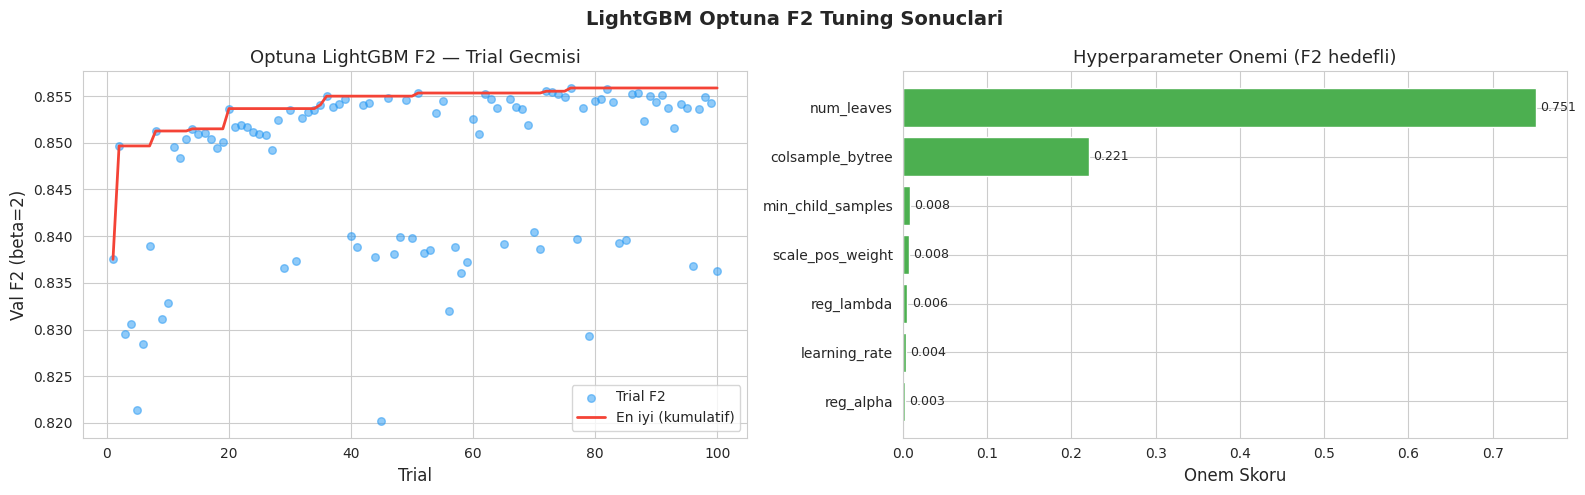

[SURE] Gorsellestirme: 3.8 sn


In [ ]:
_t_start = time.time()

trial_numbers = [t.number + 1 for t in study.trials if t.value is not None]
trial_values  = [t.value for t in study.trials if t.value is not None]
best_so_far   = [max(trial_values[:i+1]) for i in range(len(trial_values))]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ax = axes[0]
ax.scatter(trial_numbers, trial_values, alpha=0.5, s=30, color='#2196F3', label='Trial F2')
ax.plot(trial_numbers, best_so_far, color='#F44336', lw=2, label='En iyi (kumulatif)')
ax.set_xlabel('Trial', fontsize=12)
ax.set_ylabel('Val F2 (beta=2)', fontsize=12)
ax.set_title('Optuna LightGBM F2 — Trial Gecmisi', fontsize=13)
ax.legend(fontsize=10)

ax = axes[1]
try:
    importances = optuna.importance.get_param_importances(study)
    params_list = list(importances.keys())
    values_list = list(importances.values())
    bars = ax.barh(params_list[::-1], values_list[::-1], color='#4CAF50')
    ax.set_xlabel('Onem Skoru', fontsize=12)
    ax.set_title('Hyperparameter Onemi (F2 hedefli)', fontsize=13)
    for bar, val in zip(bars, values_list[::-1]):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
except Exception as e:
    ax.set_title(f'Hyperparameter Onemi (hesaplanamadi: {e})')

plt.suptitle('LightGBM Optuna F2 Tuning Sonuclari', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_BASE + 'lgb_optuna_f2_results.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] Gorsellestirme: {time.time()-_t_start:.1f} sn')

## 20. Final LightGBM — En İyi Parametrelerle Eğitim

Optuna'nın bulduğu parametrelerle final model eğitimi.
`n_estimators=3000`, `early_stopping_rounds=100` — Optuna ile aynı ayarlar.

In [ ]:
_t_start = time.time()

BEST_LGB_PARAMS = dict(study.best_params)
BEST_LGB_PARAMS.update({
    'n_estimators' : 3000,
    'device'       : 'gpu' if USE_GPU else 'cpu',
    'objective'    : 'binary',
    'metric'       : 'average_precision',
    'boosting_type': 'gbdt',
    'random_state' : 42,
    'verbose'      : -1,
    'n_jobs'       : -1,
})

print('Final LightGBM egitimi (Optuna F2 best params)...')
print('Parametreler:')
for k, v in BEST_LGB_PARAMS.items():
    print(f'  {k:<25}: {v}')
print()

lgb_model = lgb.LGBMClassifier(**BEST_LGB_PARAMS)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

elapsed_train = time.time() - _t_start
print(f'\nEgitim tamamlandi: {elapsed_train:.0f} sn | best_iteration: {lgb_model.best_iteration_}')
print(f'[SURE] Final model egitimi: {elapsed_train:.0f} sn')

Final LightGBM egitimi (Optuna F2 best params)...
Parametreler:
  scale_pos_weight         : 136.04223258236772
  num_leaves               : 462
  min_child_samples        : 154
  learning_rate            : 0.05271589167821168
  colsample_bytree         : 0.6065376665906519
  reg_alpha                : 0.0008797903219144297
  reg_lambda               : 0.23275752242325973
  n_estimators             : 3000
  device                   : cpu
  objective                : binary
  metric                   : average_precision
  boosting_type            : gbdt
  random_state             : 42
  verbose                  : -1
  n_jobs                   : -1

[200]	valid_0's average_precision: 0.841525
[400]	valid_0's average_precision: 0.847935
[600]	valid_0's average_precision: 0.851932
[800]	valid_0's average_precision: 0.853704
[1000]	valid_0's average_precision: 0.854547
[1200]	valid_0's average_precision: 0.854933
[1400]	valid_0's average_precision: 0.855299
[1600]	valid_0's average_precisio

## 21. Tahminler ve Metrikler

In [ ]:
_t_start = time.time()

val_proba  = lgb_model.predict_proba(X_val)[:, 1]
test_proba = lgb_model.predict_proba(X_test)[:, 1]

val_auc_pr   = average_precision_score(y_val,  val_proba)
test_auc_pr  = average_precision_score(y_test, test_proba)
test_auc_roc = roc_auc_score(y_test, test_proba)

print('=' * 60)
print('  LightGBM Optuna V2 AUC-PR (NaN Native) — Sonuclar')
print('=' * 60)
print(f'  Val  AUC-PR  : {val_auc_pr:.4f}  (optimize edilen metrik)')
print(f'  Test AUC-PR  : {test_auc_pr:.4f}  (birincil raporlama)')
print(f'  Test AUC-ROC : {test_auc_roc:.4f}  (ikincil metrik)')
print('=' * 60)
print(f'  Val-Test ucurumu: {val_auc_pr - test_auc_pr:+.4f}')
print(f'[SURE] Tahmin ve metrik: {time.time()-_t_start:.1f} sn')

  LightGBM Optuna V2 AUC-PR (NaN Native) — Sonuclar
  Val  AUC-PR  : 0.8559  (optimize edilen metrik)
  Test AUC-PR  : 0.6307  (birincil raporlama)
  Test AUC-ROC : 0.9179  (ikincil metrik)
  Val-Test ucurumu: +0.2251
[SURE] Tahmin ve metrik: 124.5 sn


## 22. Eşik Analizi

Operasyonel hedef: **Recall ≥ 0.85** iken mümkün olan en yüksek Precision.

In [27]:
_t_start = time.time()
RECALL_TARGET = 0.85

def f_beta(prec, rec, beta=1.0):
    denom = (beta**2 * prec + rec)
    return (1 + beta**2) * prec * rec / (denom + 1e-10) if denom > 0 else 0.0

sweep_thresholds = sorted(set([
    0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05,
    0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80,
    0.85, 0.90, 0.95
]))

rows = []
for t in sweep_thresholds:
    y_pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    rows.append({
        'Esik': t, 'Recall': rec, 'Precision': prec,
        'F1': f_beta(prec, rec, 1.0), 'F2': f_beta(prec, rec, 2.0),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

df_thr = pd.DataFrame(rows)

H = f"{'Esik':>6} {'Recall':>7} {'Prec':>7} {'F1':>6} {'F2':>6} {'TP':>5} {'FP':>6} {'FN':>5}"
SEP = '-' * len(H)
print('TEST SETI — ESIK TABLOSU (LightGBM Optuna F2, NaN Native)')
print(SEP); print(H); print(SEP)
for _, r in df_thr.iterrows():
    flags = []
    if abs(r['Recall'] - 0.85) < 0.015:   flags.append('R~85')
    if abs(r['Recall'] - 0.80) < 0.015:   flags.append('R~80')
    if abs(r['Precision'] - 0.30) < 0.03: flags.append('P~30')
    flag_str = ' < ' + '+'.join(flags) if flags else ''
    print(f"{r['Esik']:>6.3f} {r['Recall']:>7.4f} {r['Precision']:>7.4f} "
          f"{r['F1']:>6.4f} {r['F2']:>6.4f} "
          f"{int(r['TP']):>5,} {int(r['FP']):>6,} {int(r['FN']):>5,}{flag_str}")
print(SEP)

def find_best_at_recall_ge(target):
    mask = df_thr['Recall'] >= target
    return df_thr[mask].sort_values('Precision', ascending=False).iloc[0] if mask.any() else None

def find_f2_optimal():
    return df_thr.sort_values('F2', ascending=False).iloc[0]

print()
print('KRITIK NOKTALAR:')
print(f'  {"Kisit":<22} {"Esik":>6} {"Recall":>7} {"Prec":>7} {"F2":>6}')
print('  ' + '-' * 52)
for label, r in [
    ('Recall >= 0.85',    find_best_at_recall_ge(0.85)),
    ('Recall >= 0.80',    find_best_at_recall_ge(0.80)),
    ('F2 Optimal',        find_f2_optimal()),
]:
    if r is None:
        print(f'  {label:<22} — ULASILAMADI')
    else:
        print(f'  {label:<22} {r["Esik"]:>6.3f} {r["Recall"]:>7.4f} {r["Precision"]:>7.4f} {r["F2"]:>6.4f}')

op_row = find_best_at_recall_ge(RECALL_TARGET)
if op_row is not None:
    print()
    print(f'Operasyonel Precision @Recall>=85%: {op_row["Precision"]:.4f}')
else:
    print()
    print('UYARI: Recall>=85% saglanamadi. Val-test dagilim farki (kavramsal kayma) kontrol edilmeli.')
print(f'[SURE] Esik analizi: {time.time()-_t_start:.1f} sn')

TEST SETI — ESIK TABLOSU (LightGBM Optuna F2, NaN Native)
-------------------------------------------------------
  Esik  Recall    Prec     F1     F2    TP     FP    FN
-------------------------------------------------------
 0.001  0.7399  0.2867 0.4133 0.5622 3,007  7,481 1,057 < P~30
 0.002  0.7111  0.3307 0.4514 0.5781 2,890  5,850 1,174
 0.005  0.6678  0.3952 0.4965 0.5868 2,714  4,154 1,350
 0.010  0.6420  0.4497 0.5289 0.5914 2,609  3,193 1,455
 0.020  0.6179  0.5015 0.5536 0.5905 2,511  2,496 1,553
 0.030  0.6063  0.5286 0.5648 0.5890 2,464  2,197 1,600
 0.040  0.5979  0.5490 0.5724 0.5875 2,430  1,996 1,634
 0.050  0.5901  0.5634 0.5764 0.5845 2,398  1,858 1,666
 0.070  0.5800  0.5837 0.5818 0.5807 2,357  1,681 1,707
 0.100  0.5694  0.6109 0.5894 0.5772 2,314  1,474 1,750
 0.150  0.5576  0.6405 0.5962 0.5724 2,266  1,272 1,798
 0.200  0.5490  0.6599 0.5993 0.5681 2,231  1,150 1,833
 0.250  0.5423  0.6752 0.6015 0.5645 2,204  1,060 1,860
 0.300  0.5364  0.6873 0.6025 0.5610 2,

## 23. Precision-Recall Eğrisi

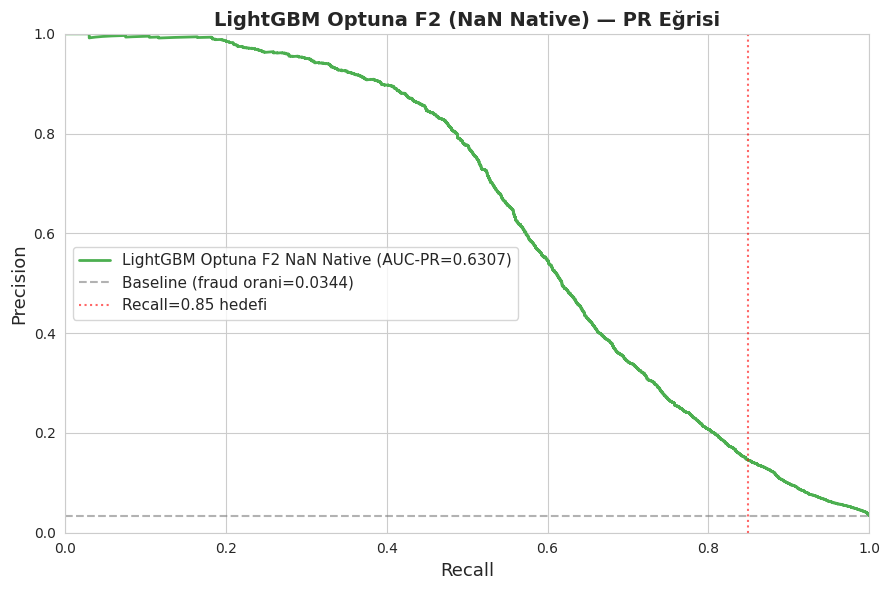

[SURE] PR egrisi: 1.5 sn


In [ ]:
_t_start = time.time()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall_curve, precision_curve, lw=2, color='#4CAF50',
        label=f'LightGBM Optuna F2 NaN Native (AUC-PR={test_auc_pr:.4f})')
ax.axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.6,
           label=f'Baseline (fraud orani={baseline_pr:.4f})')
ax.axvline(x=0.85, color='red', linestyle=':', alpha=0.6, label='Recall=0.85 hedefi')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('LightGBM Optuna F2 (NaN Native) — PR Eğrisi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(SAVE_BASE + 'lgb_optuna_f2_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] PR egrisi: {time.time()-_t_start:.1f} sn')

## 24. Özellik Önemi (Top 30)

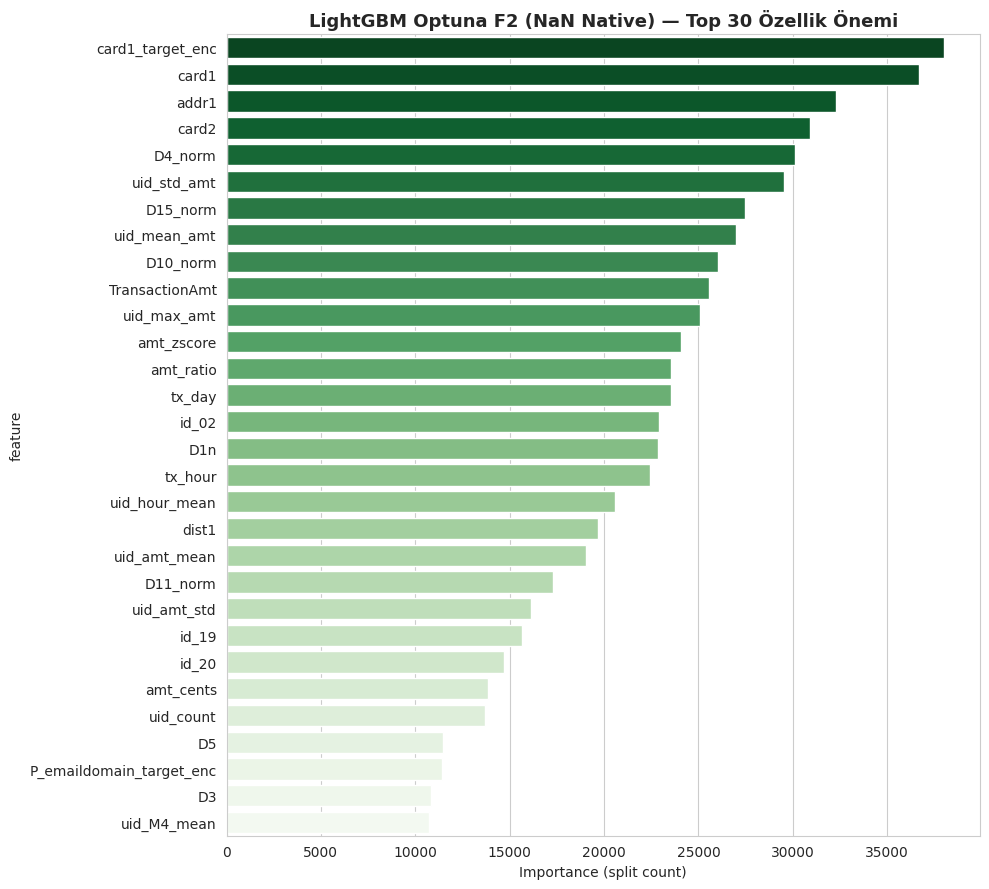

[SURE] Ozellik onemi: 0.5 sn


In [ ]:
_t_start = time.time()

feat_imp = pd.DataFrame({
    'feature'   : X_tr.columns,
    'importance': lgb_model.feature_importances_,
}).sort_values('importance', ascending=False).head(30)

fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='Greens_r', ax=ax)
ax.set_title('LightGBM Optuna F2 (NaN Native) — Top 30 Özellik Önemi',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.show()
print(f'[SURE] Ozellik onemi: {time.time()-_t_start:.1f} sn')

## 25. Model Kaydetme

In [ ]:
_t_start = time.time()

import joblib, datetime

os.makedirs(SAVE_BASE, exist_ok=True)

# Model kaydet
joblib.dump(lgb_model, SAVE_BASE + 'lgb_optuna_v2_model.pkl')
print(f'  lgb_optuna_v2_model.pkl kaydedildi.')

# Study kaydet
with open(SAVE_BASE + 'lgb_optuna_v2_study.pkl', 'wb') as _f:
    pickle.dump(study, _f)
print(f'  lgb_optuna_v2_study.pkl kaydedildi.')

# Threshold tablosunu kaydet
df_thr.to_csv(SAVE_BASE + 'lgb_optuna_v2_threshold_table.csv', index=False)
print(f'  lgb_optuna_v2_threshold_table.csv kaydedildi.')

# ── Özet veri kaydı ───────────────────────────────────────────────────────────
n_completed = len([t for t in study.trials
                   if t.state == optuna.trial.TrialState.COMPLETE])

record = {
    'tarih'             : datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model'             : 'LightGBM',
    'yontem'            : 'Optuna V2 (TPE)',
    'nan_stratejisi'    : 'NaN Native',
    'optuna_hedef'      : 'AUC-PR (average_precision_score)',
    'eval_metric'       : 'average_precision (native, objective ve erken durma)',
    'n_trials'          : n_completed,
    'optuna_sure_dk'    : round(elapsed_optuna / 60, 1),
    'best_iteration'    : lgb_model.best_iteration_,
    'best_val_auc_pr'   : round(study.best_value, 4),
    'val_auc_pr'        : round(val_auc_pr, 4),
    'test_auc_pr'       : round(test_auc_pr, 4),
    'test_auc_roc'      : round(test_auc_roc, 4),
    'prec_at_recall85'  : round(op_row['Precision'], 4) if op_row is not None else None,
    'recall_at_recall85': round(op_row['Recall'],    4) if op_row is not None else None,
    'val_test_gap'      : round(val_auc_pr - test_auc_pr, 4),
}
for k, v in study.best_params.items():
    record[f'best_{k}'] = round(v, 6) if isinstance(v, float) else v

df_record = pd.DataFrame([record])
record_path = SAVE_BASE + 'lgb_optuna_v2_record.csv'
df_record.to_csv(record_path, index=False)
print(f'  lgb_optuna_v2_record.csv kaydedildi.')
print()
print('=== VERİ KAYDI ===')
for k, v in record.items():
    print(f'  {k:<25}: {v}')

print(f'[SURE] Model ve veri kaydetme: {time.time()-_t_start:.1f} sn')

  lgb_optuna_v2_model.pkl kaydedildi.
  lgb_optuna_v2_study.pkl kaydedildi.
  lgb_optuna_v2_threshold_table.csv kaydedildi.
  lgb_optuna_v2_record.csv kaydedildi.

=== VERİ KAYDI ===
  tarih                    : 2026-05-12 17:35
  model                    : LightGBM
  yontem                   : Optuna V2 (TPE)
  nan_stratejisi           : NaN Native
  optuna_hedef             : AUC-PR (average_precision_score)
  eval_metric              : average_precision (native, objective ve erken durma)
  n_trials                 : 100
  optuna_sure_dk           : 1068.3
  best_iteration           : 2106
  best_val_auc_pr          : 0.8559
  val_auc_pr               : 0.8559
  test_auc_pr              : 0.6307
  test_auc_roc             : 0.9179
  prec_at_recall85         : None
  recall_at_recall85       : None
  val_test_gap             : 0.2251
  best_scale_pos_weight    : 136.042233
  best_num_leaves          : 462
  best_min_child_samples   : 154
  best_learning_rate       : 0.052716
  best_co

## 26. Deney Özeti ve Karşılaştırma

In [ ]:
total_elapsed = time.time() - _t0_total

print('=' * 65)
print('  DENEY ÖZETİ — LightGBM Optuna V2 AUC-PR Tuning (NaN Native)')
print('=' * 65)
print(f'  Model              : LightGBM (GBDT, NaN Native)')
print(f'  Optuna hedef       : AUC-PR (average_precision_score)')
print(f'  Optuna trials      : {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])} / {N_TRIALS}')
print(f'  En iyi Val AUC-PR  : {study.best_value:.4f}')
print(f'  Optuna sure        : {elapsed_optuna/60:.1f} dakika (kumulatif)')
print()
print(f'  Test AUC-PR        : {test_auc_pr:.4f}  <- birincil raporlama')
print(f'  Test AUC-ROC       : {test_auc_roc:.4f}')
if op_row is not None:
    print(f'  Prec @Recall>=85%  : {op_row["Precision"]:.4f}  (esik: {op_row["Esik"]:.3f})')
    print(f'  Recall @Recall>=85%: {op_row["Recall"]:.4f}  ✓ HEDEF SAGLANDI')
else:
    print(f'  Recall>=85%        : ULASILAMADI (kavramsal kayma)')
print()
print('  En iyi parametreler:')
for k, v in study.best_params.items():
    print(f'    {k:<25}: {v}')
print(f'  best_iteration     : {lgb_model.best_iteration_}')
print()
print('  KARSILASTIRMA (LightGBM):')
print(f'  {"Yontem":<35} {"Hedef":>8} {"Val F2/PR":>10} {"Test PR":>9} {"ROC":>7}')
print('  ' + '-' * 72)
print(f'  {"LightGBM Optuna V2 (AUC-PR, bu calisma)":<35} {"AUC-PR":>8} {study.best_value:>10.4f} {test_auc_pr:>9.4f} {test_auc_roc:>7.4f}')
print(f'  {"LightGBM Optuna F2 (v1)":<35} {"AUC-PR":>8} {f"{study.best_value:>10.4f}":>10} {"0.6323":>9} {"0.9155":>7}')
print()
print(f'  Toplam sure        : {total_elapsed/60:.1f} dakika')
print('=' * 65)

  DENEY ÖZETİ — LightGBM Optuna V2 AUC-PR Tuning (NaN Native)
  Model              : LightGBM (GBDT, NaN Native)
  Optuna hedef       : AUC-PR (average_precision_score)
  Optuna trials      : 100 / 100
  En iyi Val AUC-PR  : 0.8559
  Optuna sure        : 1068.3 dakika (kumulatif)

  Test AUC-PR        : 0.6307  <- birincil raporlama
  Test AUC-ROC       : 0.9179
  Recall>=85%        : ULASILAMADI (kavramsal kayma)

  En iyi parametreler:
    scale_pos_weight         : 136.04223258236772
    num_leaves               : 462
    min_child_samples        : 154
    learning_rate            : 0.05271589167821168
    colsample_bytree         : 0.6065376665906519
    reg_alpha                : 0.0008797903219144297
    reg_lambda               : 0.23275752242325973
  best_iteration     : 2106

  KARSILASTIRMA (LightGBM):
  Yontem                                 Hedef  Val F2/PR   Test PR     ROC
  ------------------------------------------------------------------------
  LightGBM Optuna V2 (AUC